## Assignment: $k$ Means Clustering

### `! git clone https://github.com/ds3001f25/clustering_assignment.git`

### **Do two questions in total: "Q1+Q2" or "Q1+Q3"**

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

## Q1

**Q1.** This is a question about clustering. We want to investigate how adjusting the "noisiness" of the data impacts the quality of the algorithm and the difficulty of picking $k$.

1. Run the code below, which creates four datasets: `df0_125`, `df0_25`, `df0_5`, `df1_0`, and `df2_0`. Each data set is created by increasing the amount of `noise` (standard deviation) around the cluster centers, from `0.125` to `0.25` to `0.5` to `1.0` to `2.0`.

```
import numpy as np
import pandas as pd

def createData(noise,N=50):
    np.random.seed(100) # Set the seed for replicability
    # Generate (x1,x2,g) triples:
    X1 = np.array([np.random.normal(1,noise,N),np.random.normal(1,noise,N)])
    X2 = np.array([np.random.normal(3,noise,N),np.random.normal(2,noise,N)])
    X3 = np.array([np.random.normal(5,noise,N),np.random.normal(3,noise,N)])
    # Concatenate into one data frame
    gdf1 = pd.DataFrame({'x1':X1[0,:],'x2':X1[1,:],'group':'a'})
    gdf2 = pd.DataFrame({'x1':X2[0,:],'x2':X2[1,:],'group':'b'})
    gdf3 = pd.DataFrame({'x1':X3[0,:],'x2':X3[1,:],'group':'c'})
    df = pd.concat([gdf1,gdf2,gdf3],axis=0)
    return df

df0_125 = createData(0.125)
df0_25 = createData(0.25)
df0_5 = createData(0.5)
df1_0 = createData(1.0)
df2_0 = createData(2.0)
```

2. Make scatterplots of the $(X1,X2)$ points by group for each of the datasets. As the `noise` goes up from 0.125 to 2.0, what happens to the visual distinctness of the clusters?
3. Create a scree plot for each of the datasets. Describe how the level of `noise` affects the scree plot (particularly the presence of a clear "elbow") and your ability to definitively select a $k$. (Pay attention to the vertical axis across plots, or put all the scree curves on a single canvas.)
4. Explain the intuition of the elbow, using this numerical simulation as an example.

### Q1.1

In [2]:
def createData(noise,N=50):
    np.random.seed(100) # Set the seed for replicability
    # Generate (x1,x2,g) triples:
    X1 = np.array([np.random.normal(1,noise,N),np.random.normal(1,noise,N)])
    X2 = np.array([np.random.normal(3,noise,N),np.random.normal(2,noise,N)])
    X3 = np.array([np.random.normal(5,noise,N),np.random.normal(3,noise,N)])
    # Concatenate into one data frame
    gdf1 = pd.DataFrame({'x1':X1[0,:],'x2':X1[1,:],'group':'a'})
    gdf2 = pd.DataFrame({'x1':X2[0,:],'x2':X2[1,:],'group':'b'})
    gdf3 = pd.DataFrame({'x1':X3[0,:],'x2':X3[1,:],'group':'c'})
    df = pd.concat([gdf1,gdf2,gdf3],axis=0)
    return df

df0_125 = createData(0.125)
df0_25 = createData(0.25)
df0_5 = createData(0.5)
df1_0 = createData(1.0)
df2_0 = createData(2.0)

### Q1.2

I'm too lazy to write a for loop, so I'm just gonna copy and paste the line.

[Text(0.5, 1.0, 'Noise, 0.125')]

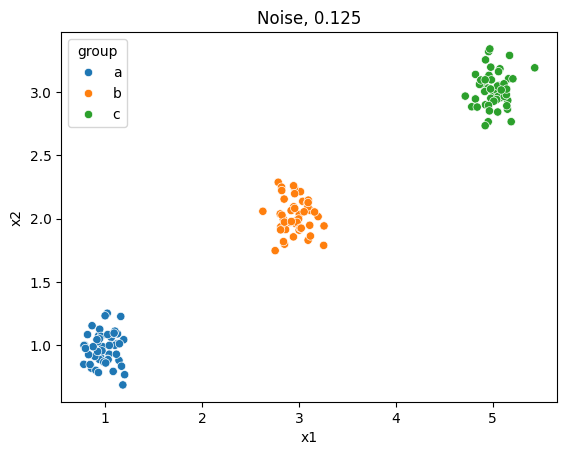

In [3]:
sns.scatterplot(data=df0_125, x='x1', y='x2', hue='group').set(title='Noise, 0.125')

[Text(0.5, 1.0, 'Noise, 0.25')]

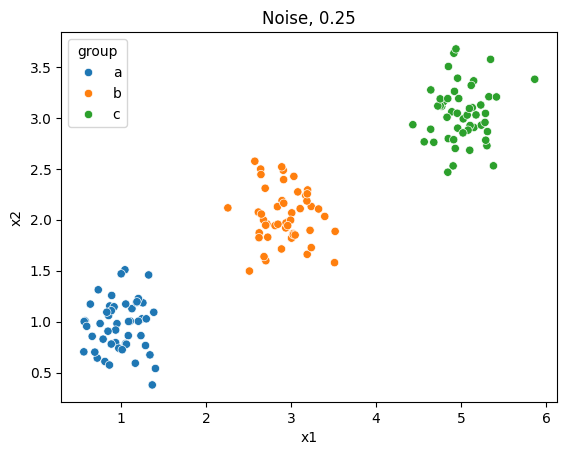

In [4]:
sns.scatterplot(data=df0_25, x='x1', y='x2', hue='group').set(title='Noise, 0.25')

[Text(0.5, 1.0, 'Noise, 0.5')]

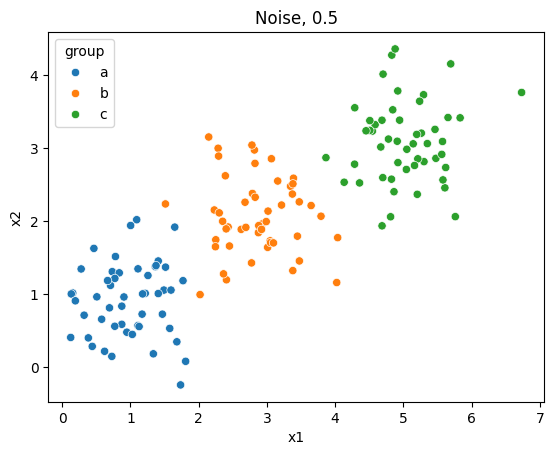

In [5]:
sns.scatterplot(data=df0_5, x='x1', y='x2', hue='group').set(title='Noise, 0.5')

[Text(0.5, 1.0, 'Noise, 1.0')]

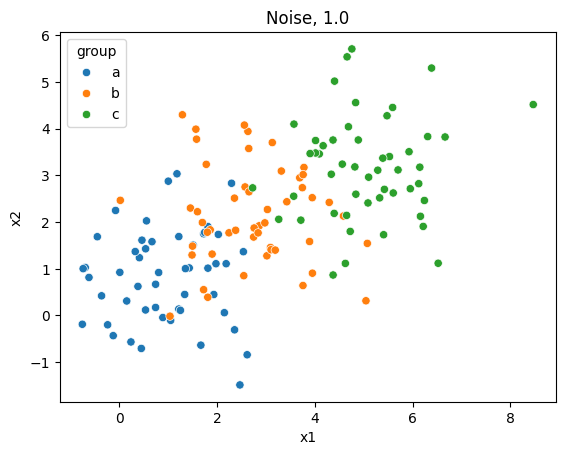

In [6]:
sns.scatterplot(data=df1_0, x='x1', y='x2', hue='group').set(title='Noise, 1.0')

[Text(0.5, 1.0, 'Noise, 2.0')]

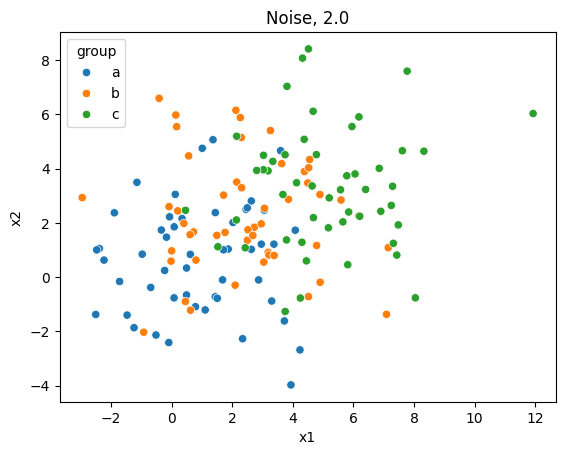

In [7]:
sns.scatterplot(data=df2_0, x='x1', y='x2', hue='group').set(title='Noise, 2.0')

So in conclusion, as the noise increases the spread of each cluster increases. This makes a lot of sense, and obviously the visual distinctness of the clusters starts to become no longer easily separable in noise = 1.0 and evidently, noise = 2.0.

### Q1.3

Ok before I do all of this I assume all of the groups need to be dropped, since that's the "cluster" that we want and that would heavily skew the actual clusters we get.

In [8]:
df0_125_dropped = df0_125.drop('group', axis=1)
df0_25_dropped = df0_25.drop('group', axis=1)
df0_5_dropped = df0_5.drop('group', axis=1)
df1_0_dropped = df1_0.drop('group', axis=1)
df2_0_dropped = df2_0.drop('group', axis=1)

And... I know I said I was too lazy to for loop it, but this time I don't feel like copy pasting this massive chunk of code like, 5 times, so I'll just write the loop.

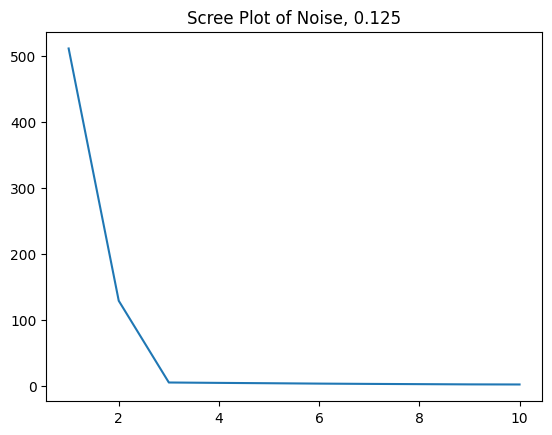

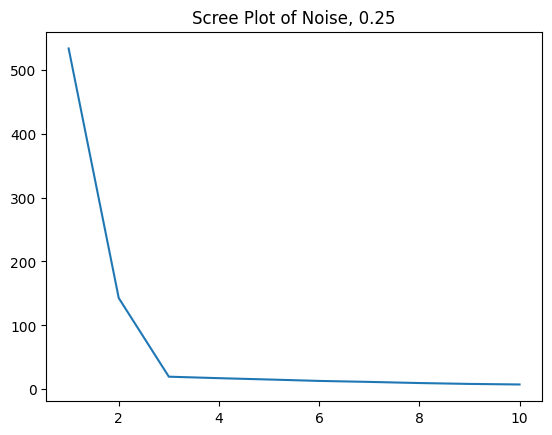

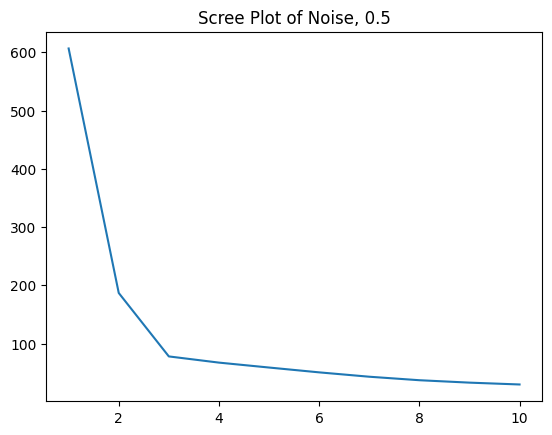

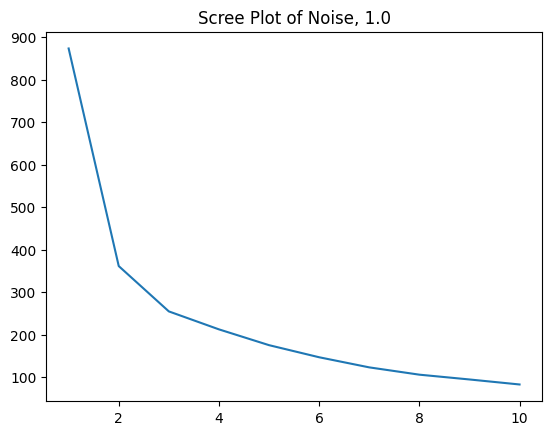

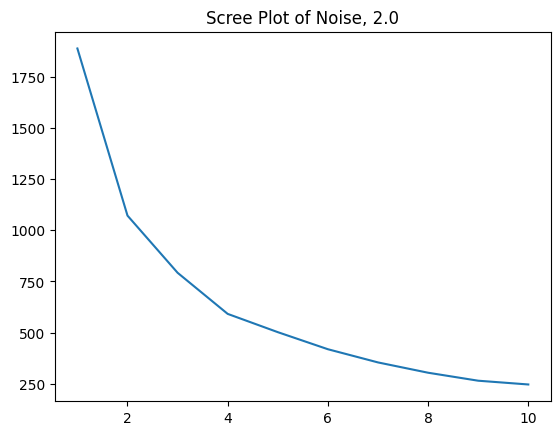

In [9]:
# i band for band line for line STOLE this code from the lecture notebooks, btw
def maxmin(x):
    x = (x-min(x))/(max(x)-min(x))
    return x

# i will add this portion so that I don't have to copy paste this code 5 times
dfs = [df0_125_dropped, df0_25_dropped, df0_5_dropped, df1_0_dropped, df2_0_dropped]
df_noises = [0.125, 0.25, 0.5, 1.0, 2.0]
for i in range(len(dfs)):
    k_bar = 10
    SSE = []
    for k in range(k_bar):
        model = KMeans(n_clusters=k+1, max_iter=300, n_init=10, random_state=0)
        model = model.fit(dfs[i])
        SSE.append(model.inertia_)
        
    scree_plot = sns.lineplot(x=np.arange(1,k_bar+1), y=SSE).set_title(f'Scree Plot of Noise, {df_noises[i]}')
    plt.show()

2. Make scatterplots of the $(X1,X2)$ points by group for each of the datasets. As the `noise` goes up from 0.125 to 2.0, what happens to the visual distinctness of the clusters?
3. Create a scree plot for each of the datasets. Describe how the level of `noise` affects the scree plot (particularly the presence of a clear "elbow") and your ability to definitively select a $k$. (Pay attention to the vertical axis across plots, or put all the scree curves on a single canvas.)
4. Explain the intuition of the elbow, using this numerical simulation as an example.

I'll answer this in two parts - so firstly, the noise affects the scree plot by having increased noise equate to increase difficulty in finding the elbow. That is, with noises below 1.0 (and even kind of 1.0), you can tell that the elbow is at 3. However, at noise 2.0, it is very very difficult to tell where the actual elbow is visually. Thus, my ability to visually select a $k$ is heavily hindered because I don't know (without background information) what the optimal $k$ would be here exactly. Now, another interesting note is the vertical axis - the vertical axis is obviously SSE, and that makes a lot of sense because with increasing noise, we have a lot higher SSE than the lower noise plots.

### Q1.4

The intuition of the elbow is that we optimally want to find a point where we are beginning to minimize SSE, without going into diminishing returns. That is, we want the midpoint between where we're starting to create enough clusters to meaningfully handle the data, but not going overboard with either diminishing returns or even too many clusters that wouldn't be helpful or meaningful for the separation of the data. That being said though, with increasing noise with data points it becomes a lot harder to distinguish what is and isn't a meaningful number of clusters that isn't too many to over cluster the data into groups that don't make sense.

## Q2

**Q2.** This question is a case study on clustering.

1. Load the `2022 election cycle fundraising.csv` file in the `./data` folder. This has campaign finance data for the 2022 election for House and Senate candidates. We're going to focus on the total amount they raised, `Raised`, the total amount they spent, `Spent`, their available `Cash on Hand`, and their `Debts`. The variables denominated in dollars are messy and require cleaning. How do you handle it?
2. Max-min normalize `Raised` and `Spent`. Use a scree plot to determine the optimal number of clusters for the $k$ means clustering algorithm. Make a scatter plot of `Raised` against `Spent` and hue the dots by their cluster membership. What do you see? Which politicians comprise the smallest two clusters? If necessary, look up some of these races to see how close they were.
3. Repeat part 2, but for `Cash on Hand` and `Debts`. Compare your results with part 2. Why might this be? If necessary, look up some of these races to see how close they were.
4. Use $k$ means clustering with all four numeric variables. How do your results compare to the previous two parts?
5. Did the $k$-MC algorithm find useful patterns for you in analyzing the election?

### Q2.1

In [26]:
elections_df = pd.read_csv('./data/2022 election cycle fundraising.csv')

Now we'll only keep those 4 columns in particular.

In [27]:
elections_df.head()

,index,Member,Party,State,Chamber,Raised,Spent,Cash on Hand,Debts
0,0,Abigail Spanberger,Democratic,Virginia,House,"$7,719,396","$7,449,678","$851,851",$0
1,1,Adam Kinzinger,Republican,Illinois,House,"$2,192,741","$1,243,502","$2,472,888",$0
2,2,Adam Schiff,Democratic,California,House,"$20,993,041","$13,957,854","$20,942,888",$0
3,3,Adam Smith,Democratic,Washington,House,"$1,211,111","$1,173,466","$623,472",$0
4,4,Adrian Smith,Republican,Nebraska,House,"$1,617,611","$1,664,674","$1,098,579",$0


We'll handle the dollar sign and commas the same as before, kinda! The most important thing to note here is that there are multiple commas, so I'll just write some regex to get rid of them.

In [28]:
elections_df_cleaned = elections_df.copy()
elections_df_cleaned['Raised'] = pd.to_numeric(elections_df_cleaned['Raised'].replace({r'\$':'', ',':''}, regex=True), errors='coerce')
elections_df_cleaned['Spent'] = pd.to_numeric(elections_df_cleaned['Spent'].replace({r'\$':'', ',':''}, regex=True), errors='coerce')
elections_df_cleaned['Cash on Hand'] = pd.to_numeric(elections_df_cleaned['Cash on Hand'].replace({r'\$':'', ',':''}, regex=True), errors='coerce')
elections_df_cleaned['Debts'] = pd.to_numeric(elections_df_cleaned['Debts'].replace({r'\$':'', ',':''}, regex=True), errors='coerce')

In [29]:
elections_df_cleaned.head()

,index,Member,Party,State,Chamber,Raised,Spent,Cash on Hand,Debts
0,0,Abigail Spanberger,Democratic,Virginia,House,7719396,7449678,851851,0
1,1,Adam Kinzinger,Republican,Illinois,House,2192741,1243502,2472888,0
2,2,Adam Schiff,Democratic,California,House,20993041,13957854,20942888,0
3,3,Adam Smith,Democratic,Washington,House,1211111,1173466,623472,0
4,4,Adrian Smith,Republican,Nebraska,House,1617611,1664674,1098579,0


In [30]:
elections_df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537 entries, 0 to 536
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   index         537 non-null    int64 
 1   Member        537 non-null    object
 2   Party         537 non-null    object
 3   State         537 non-null    object
 4   Chamber       537 non-null    object
 5   Raised        537 non-null    int64 
 6   Spent         537 non-null    int64 
 7   Cash on Hand  537 non-null    int64 
 8   Debts         537 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 37.9+ KB


And now we're all good to go and cleaned.

### Q2.2

In [49]:
def maxmin(z):
    w = (z-np.min(z))/(np.max(z)-np.min(z))
    return w

In [50]:
scaled_elections_df = elections_df_cleaned.copy()
scaled_elections_df['Raised'] = maxmin(scaled_elections_df['Raised'])
scaled_elections_df['Spent'] = maxmin(scaled_elections_df['Spent'])

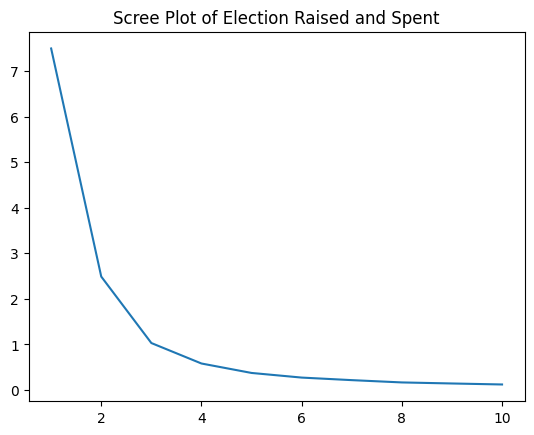

In [51]:
k_bar = 10
SSE = []
for k in range(k_bar):
    model = KMeans(n_clusters=k+1, max_iter=300, n_init=10, random_state=0)
    model = model.fit(scaled_elections_df[['Raised','Spent']])
    SSE.append(model.inertia_)
    
scree_plot = sns.lineplot(x=np.arange(1,k_bar+1), y=SSE).set_title(f'Scree Plot of Election Raised and Spent')

Elbow here looks to be 3 clusters.

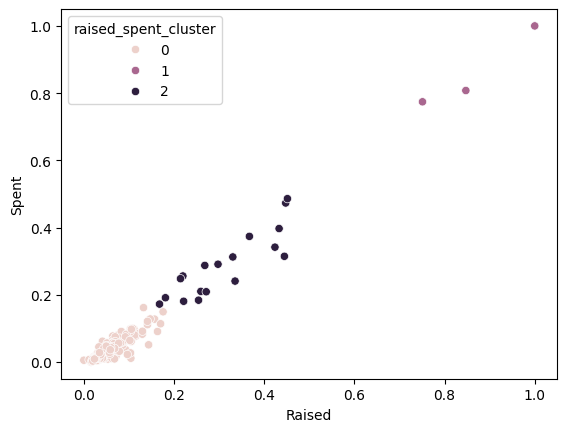

In [52]:
model = KMeans(n_clusters=3, max_iter=300, n_init=10, random_state=0)
model = model.fit(scaled_elections_df[['Raised','Spent']])
scaled_elections_df['raised_spent_cluster'] = model.fit_predict(scaled_elections_df[['Raised','Spent']])
fig = sns.scatterplot(data=scaled_elections_df, x="Raised", y="Spent", hue='raised_spent_cluster')

In [53]:
scaled_elections_df[scaled_elections_df['raised_spent_cluster'] == 1]

,index,Member,Party,State,Chamber,Raised,Spent,Cash on Hand,Debts,raised_spent_cluster
340,340,Mark Kelly,Democratic,Arizona,Senate,0.847210,0.807760,13186127,0,1
417,417,Raphael Warnock,Democratic,Georgia,Senate,1.000000,1.000000,22762985,0,1
523,523,Val Demings,Democratic,Florida,House,0.751061,0.774181,6647641,0,1


In [54]:
scaled_elections_df[scaled_elections_df['raised_spent_cluster'] == 2]

,index,Member,Party,State,Chamber,Raised,Spent,Cash on Hand,Debts,raised_spent_cluster
2,2,Adam Schiff,Democratic,California,House,0.254404,0.183753,20942888,0,2
87,87,Catherine Cortez Masto,Democratic,Nevada,Senate,0.447666,0.472999,5089745,0,2
89,89,Chuck Schumer,Democratic,New York,Senate,0.423863,0.341554,20231213,0,2
115,115,Dan Crenshaw,Republican,Texas,House,0.181001,0.191054,1876149,0,2
261,261,John Kennedy,Republican,Louisiana,Senate,0.335412,0.240608,15530074,0,2
290,290,Katie Porter,Democratic,California,House,0.259505,0.209938,15762568,0,2
298,298,Kevin McCarthy,Republican,California,House,0.297585,0.290764,7507326,0,2
326,326,Maggie Hassan,Democratic,New Hampshire,Senate,0.367193,0.373632,4813508,0,2
328,328,Marco Rubio,Republican,Florida,Senate,0.433063,0.396961,9631856,0,2
357,357,Michael Bennet,Democratic,Colorado,Senate,0.221362,0.180538,4898614,374819,2


Yeah so looks like the groups include Mark Kelly, Val Delmings, Raphale Warnock, and some big names in the other part like John Kennedy, Marco Rubio, Nancy Pelosi, Ted Cruz, Tim Scott, Chuck Schumer, etc. Clearly there are some groups of big spenders/raisers, moderate spenders/raisers, and lower spenders/raisers.

### Q2.3

In [55]:
scaled_elections_df['Cash on Hand'] = maxmin(scaled_elections_df['Cash on Hand'])
scaled_elections_df['Debts'] = maxmin(scaled_elections_df['Debts'])

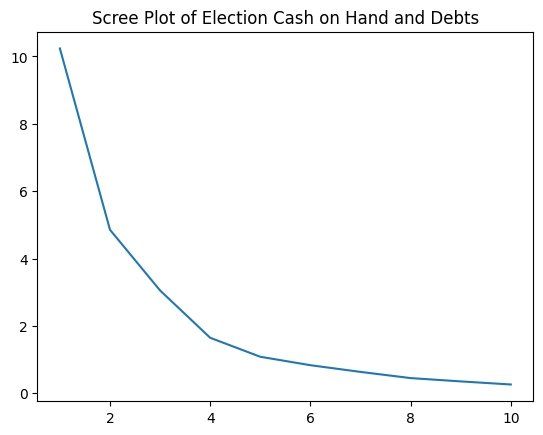

In [56]:
k_bar = 10
SSE = []
for k in range(k_bar):
    model = KMeans(n_clusters=k+1, max_iter=300, n_init=10, random_state=0)
    model = model.fit(scaled_elections_df[['Cash on Hand', 'Debts']])
    SSE.append(model.inertia_)
    
scree_plot = sns.lineplot(x=np.arange(1,k_bar+1), y=SSE).set_title(f'Scree Plot of Election Cash on Hand and Debts')

Hmmm... The elbow here kinda looks like it's at 4? So let's do it with k = 4.

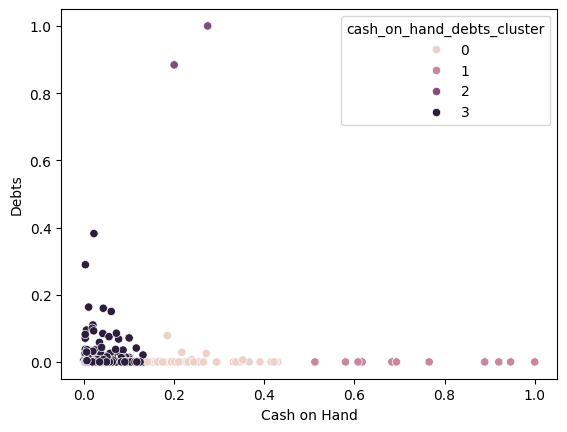

In [57]:
model = KMeans(n_clusters=4, max_iter=300, n_init=10, random_state=0)
model = model.fit(scaled_elections_df[['Cash on Hand', 'Debts']])
scaled_elections_df['cash_on_hand_debts_cluster'] = model.fit_predict(scaled_elections_df[['Cash on Hand','Debts']])
fig = sns.scatterplot(data=scaled_elections_df, x="Cash on Hand", y="Debts", hue='cash_on_hand_debts_cluster')

Yeah, looks pretty good. Let's take a look at the two least again, which is again clusters 1 and 2.

In [58]:
scaled_elections_df[scaled_elections_df['cash_on_hand_debts_cluster'] == 1]

,index,Member,Party,State,Chamber,Raised,Spent,Cash on Hand,Debts,raised_spent_cluster,cash_on_hand_debts_cluster
2,2,Adam Schiff,Democratic,California,House,0.254404,0.183753,0.920268,0.0,2,1
89,89,Chuck Schumer,Democratic,New York,Senate,0.423863,0.341554,0.889092,0.0,2,1
261,261,John Kennedy,Republican,Louisiana,Senate,0.335412,0.240608,0.683153,0.0,2,1
267,267,John Thune,Republican,South Dakota,Senate,0.092727,0.036377,0.765940,0.0,0,1
274,274,Josh Gottheimer,Democratic,New Jersey,House,0.103522,0.026925,0.617185,0.0,0,1
290,290,Katie Porter,Democratic,California,House,0.259505,0.209938,0.693338,0.0,2,1
310,310,Lindsey Graham,Republican,South Carolina,Senate,0.091874,0.070715,0.608044,0.0,0,1
340,340,Mark Kelly,Democratic,Arizona,Senate,0.847210,0.807760,0.580473,0.0,1,1
412,412,Raja Krishnamoorthi,Democratic,Illinois,House,0.104928,0.061064,0.512454,0.0,0,1
417,417,Raphael Warnock,Democratic,Georgia,Senate,1.000000,1.000000,1.000000,0.0,1,1


In [59]:
scaled_elections_df[scaled_elections_df['cash_on_hand_debts_cluster'] == 2]

,index,Member,Party,State,Chamber,Raised,Spent,Cash on Hand,Debts,raised_spent_cluster,cash_on_hand_debts_cluster
133,133,David Trone,Democratic,Maryland,House,0.163436,0.090549,0.274716,1.000000,0,2
442,442,Ron Johnson,Republican,Wisconsin,Senate,0.330431,0.312424,0.200342,0.884067,2,2


Yeah so looks like the groups include David Trone, Ron Johnson, Mark Kelly, John Kennedy, Chuck Schumer, Tim Scott, etc. The clusters here are pretty evident - no debt high cash on hand, low debt mid cash on hand, low debt low cash on hand, and lowish cash with high debt. The clusters here make a lot of sense.

### Q2.4

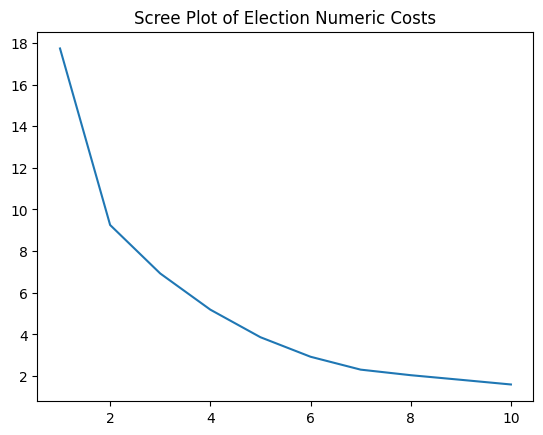

In [61]:
k_bar = 10
SSE = []
for k in range(k_bar):
    model = KMeans(n_clusters=k+1, max_iter=300, n_init=10, random_state=0)
    model = model.fit(scaled_elections_df[['Raised', 'Spent', 'Cash on Hand', 'Debts']])
    SSE.append(model.inertia_)
    
scree_plot = sns.lineplot(x=np.arange(1,k_bar+1), y=SSE).set_title(f'Scree Plot of Election Numeric Costs')

I'll argue that the elbow here is probably like, k=3 since that's when the line genuinely starts flattening out (and k=2 doesn't sound very interesting). So let's go with that.

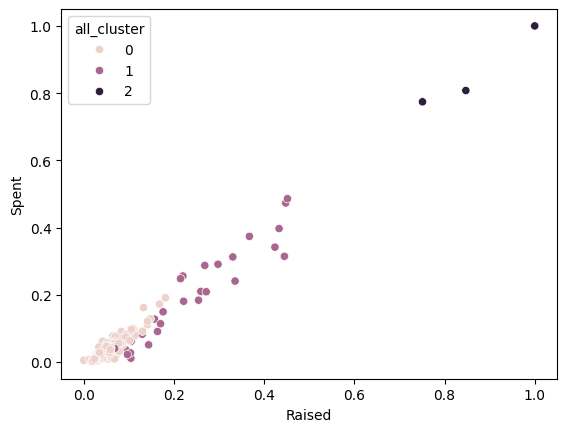

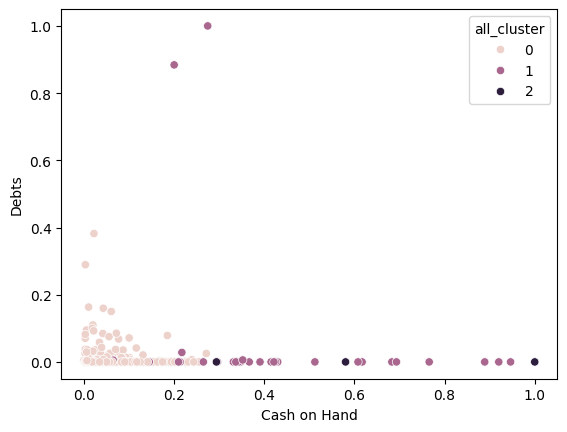

In [64]:
model = KMeans(n_clusters=3, max_iter=300, n_init=10, random_state=0)
model = model.fit(scaled_elections_df[['Raised', 'Spent', 'Cash on Hand', 'Debts']])
scaled_elections_df['all_cluster'] = model.fit_predict(scaled_elections_df[['Raised', 'Spent', 'Cash on Hand', 'Debts']])
fig = sns.scatterplot(data=scaled_elections_df, x="Raised", y="Spent", hue='all_cluster')
plt.show()
fig = sns.scatterplot(data=scaled_elections_df, x="Cash on Hand", y="Debts", hue='all_cluster')
plt.show()

So it looks like the clusters are definitely different here, which makes sense - I mean honestly straight up, for cash on hand and debts the previous was k=4 and not k=3. But in any case - it is very different. Seems like more than likely, the clusters were formed with a heavy influence from raised and spent, since the clusters look kind of similar to what we did before in 2.2! But cash on hand and debts have very different clusters, aside from cluster 0.

### Q2.5

It certainly gave some interesting patterns - that is, the similarity in clustering when doing multi-dimensional seems to take heavy influence from the raised and spent dollar amounts, which makes sense - I would imagine that debts and cash on hand does not have that much crazy relevance in clusters in comparison to these two cost wise numericals. Likewise, it's easy to tell via the clusters what sort of groups arise (groups of high spenders and raisers, etc.) and identify their parties and candidates so that I could look closer into these candidates individually. Overall, an interesting visualization and the k-MC algo definitely helped me better understand this dataset.

## Q3 (didn't do it)

**Q3.** This question is a case study on clustering.

1. Load the `SIPRI Military Expenditure Database.csv` file in the `./data` folder. This has data about military spending by country. Filter the rows to select only the year 2020, and drop all rows with missing values. I ended up with 148 countries. Is any further cleaning of the variables required?
2. Max-min normalize `Spending (2020 USD)` and `Spending per Capita`. Use a scree plot to determine the optimal number of clusters for the $k$ means clustering algorithm. Make a scatter plot of `Spending (2020 USD)` and `Spending per Capita`, and hue the dots by their cluster membership. Compute a describe table conditional on cluster membership (i.e. `.groupby(cluster).describe()`). What do you see? Where is the United States? Do you notice any patterns in the cluster membership?
3. Repeat part 2 for `Percent of Government Spending` and `Percent of GDP`. How do your results compare to part 2?
4. Use $k$ means clustering with all four numeric variables: `Spending (2020 USD)`, `Spending per Capita`, `Percent of Government Spending`, and `Percent of GDP`. How do your results compare to the previous two parts? 
5. Did the $k$-MC algorithm find any useful patterns for you in analyzing the spending?